In [1]:
# @title Instalar librerías
%%capture
!pip install openneuro-py
!pip install mne
!pip install mne-bids
!pip install autoreject
!pip install pybids
!pip install mne-icalabel
!pip install pyprep
!apt-get install -y tree

In [2]:
# @title Importar librerías
import matplotlib.pyplot as plt
import pandas as pd
import json
import openneuro as on
import mne
import autoreject
from mne.preprocessing import ICA
from mne_icalabel import label_components
import mne_bids
import bids
import ipywidgets
import numpy as np
import pyprep

¡Bienvenidos!

En esta introducción se dará una mirada a un flujo muy básico de preprocesamiento y procesamiento de análisis EEG.

La idea de este tutorial es aprender un flujo general de pre procesamiento que pueda ser utilizado a cualquier señal de EEG leída mediante MNE.

El pre procesamiento es una etapa necesaria para el análisis de datos EEG ya que los instrumentos que utilizamos para capturar actividad cerebral no siempre captan únicamente ésta, sino que también pueden verse nutridas por artefactos.

Podemos tener una idea general de los pasos que se seguirán durante esta serie de tutoriales.

<br>

<figure style="text-align:left; margin: 1.25rem 0;background:#fff;">
  <img src="https://raw.githubusercontent.com/da-falcon/eeg_lecture/refs/heads/main/resources/flow_03.png"
       alt="montaje"
       style="display:block; margin:0 auto; max-width:100%; width:1080px; height:auto;">
  <figcaption style="margin-top:.5rem; color:#555;">Flujo general de este notebook.</figcaption>
</figure>

<br>

En el primer paso **Signal retrieval and continous processing phase** realizaremos los siguientes procesos.

<br>

<figure style="text-align:left; margin: 1.25rem 0;background:#fff;">
  <img src="https://raw.githubusercontent.com/da-falcon/eeg_lecture/refs/heads/main/resources/flow_01.png"
       alt="montaje"
       style="display:block; margin:0 auto; max-width:100%; width:1080px; height:auto;">
  <figcaption style="margin-top:.5rem; color:#555;">Flujo de la primera parte.</figcaption>
</figure>

<br>

# Obtención de datos
Los datos que se utilizaran en este tutorial serán obtenidos del repositorio <a href="https://openneuro.org/"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      **Open Neuro**
  </a>, el cual almacena diversos conjuntos de datos neurofisiológicos de investigaciones publicadas y compartidas en el marco de la ciencia abierta. En este caso, la información de los datos que utilizaremos es la siguiente:

> Prakash Mishra, Tapan K. Gandhi, and Saurabh R. Gandhi (2026). A multimodal dataset of EEG, eye-tracking, and physiological signals during smartphone interaction. OpenNeuro. [Dataset] doi: doi:10.18112/openneuro.ds007537.v2.0.1

  Así como otros repositorios, **Open Neuro** utiliza un formato para la organización de sus datos, lo que permite que cualquier persona (como nosotross) pueda utilizarlos con facilidad en el futuro. Este formato es el **BIDS**

<a href="https://www.neuroinfo.org/gsp"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      **Brain Genomics Superstruct Project**
  </a>

<a href="https://www.ebrains.eu/"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      **Ebrains**
  </a>

<a href="https://brainlife.io/about/"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      **Brainlife**
  </a>


Y más.

<h1>Base de datos normal Vs BIDS</h1>
<figure style="text-align:center; margin: 1.25rem 0;">
  <img src="https://bids.neuroimaging.io/assets/img/dicom-reorganization-transparent-white_1000x477.png"
       alt="Dataset EEG-BIDS"
       style="display:block; margin:0 auto; max-width:100%; width:600px; height:auto;">
  <figcaption style="margin-top:.5rem; color:#555;">Reorganización DICOM → BIDS.</figcaption>
</figure>

<h1>¿Qué hay dentro de cada archivo?</h1>
<figure style="text-align:center; margin: 1.25rem 0;">
  <img src="https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41597-019-0104-8/MediaObjects/41597_2019_104_Fig1_HTML.png"
       alt="Dataset EEG-BIDS"
       style="display:block; margin:0 auto; max-width:100%; width:600px; height:auto;">
  <figcaption style="margin-top:.5rem; color:#555;">Estructura interna de un dataset BIDS.</figcaption>
</figure>




In [3]:
# @title Crear carpeta para los datos
!mkdir data

In [4]:
# @title El API de open neuro para descargar la base de datos
on.download(
    dataset="ds007537",  # OpenNeuro Accession Number
    target_dir="/content/data",  # Carpeta donde se guardará el dataset
    include=["sub-02"],  # Solo incluir los participantes sub-104
)

🌍 Preparing to download ds007537 …
📥 Checking 20 files, downloading as needed (5 concurrent downloads). 


Output()

✅ Finished downloading ds007537 (downloaded 20 files and 301.4 MB).


In [5]:
#@title Estructura de los datos

!tree

.
├── data
│   ├── CHANGES
│   ├── dataset_description.json
│   ├── participants.json
│   ├── participants.tsv
│   ├── README
│   └── sub-02
│       ├── beh
│       │   ├── sub-02_task-phoneuse_recording-cyclopean_physioevents.json
│       │   ├── sub-02_task-phoneuse_recording-cyclopean_physioevents.tsv.gz
│       │   ├── sub-02_task-phoneuse_recording-cyclopean_physio.json
│       │   ├── sub-02_task-phoneuse_recording-cyclopean_physio.tsv.gz
│       │   ├── sub-02_task-phoneuse_recording-imu_physio.json
│       │   └── sub-02_task-phoneuse_recording-imu_physio.tsv.gz
│       └── eeg
│           ├── sub-02_space-CapTrak_coordsystem.json
│           ├── sub-02_space-CapTrak_electrodes.tsv
│           ├── sub-02_task-phoneuse_channels.tsv
│           ├── sub-02_task-phoneuse_eeg.eeg
│           ├── sub-02_task-phoneuse_eeg.json
│           ├── sub-02_task-phoneuse_eeg.vhdr
│           ├── sub-02_task-phoneuse_eeg.vmrk
│           ├── sub-02_task-phoneuse_events.json
│           └── sub

# Descripción de la base

Luego de haber usado el API de Open Neuro, podemos usar la librería BIDS para ver la estructura de la base.

Cosas como el layout (el panorama general), la lista de sujetos, la lista de tareas (experimentales), los tipos de datos (eeg, fmri, etc).

In [6]:
# @title Descripción de la base
layout = bids.BIDSLayout("/content/data")  # guarda la estructura de las carpetas y contenidos en la variable layout


subjects_list = (layout.get_subjects())  # de la variable layout, extraemos los nombres que por organización deberían corresponder a los sujetos.


tasks_list = layout.get_tasks()  # de la variable layout, extraemos los nom

datatypes = layout.get_datatypes()  # de la variable layout, extraemos los datatypes.


files_list = (layout.get_files())  # de la variable layout, extraemos los nombres de los archivos.


print(layout)

print(f"""
Subjects in the database:
{subjects_list}

Tasks in the database:
{tasks_list}

Data types in the database:
{datatypes}

Files in the database:
{files_list}
""")

layout.get_dataset_description()

BIDS Layout: .../content/data | Subjects: 1 | Sessions: 0 | Runs: 0

Subjects in the database:
['02']

Tasks in the database:
['phoneuse']

Data types in the database:
['beh', 'eeg']

Files in the database:
{'/content/data/CHANGES': <BIDSFile filename='/content/data/CHANGES'>, '/content/data/participants.tsv': <BIDSDataFile filename='/content/data/participants.tsv'>, '/content/data/README': <BIDSFile filename='/content/data/README'>, '/content/data/participants.json': <BIDSJSONFile filename='/content/data/participants.json'>, '/content/data/dataset_description.json': <BIDSJSONFile filename='/content/data/dataset_description.json'>, '/content/data/sub-02/beh/sub-02_task-phoneuse_recording-imu_physio.tsv.gz': <BIDSDataFile filename='/content/data/sub-02/beh/sub-02_task-phoneuse_recording-imu_physio.tsv.gz'>, '/content/data/sub-02/beh/sub-02_task-phoneuse_recording-cyclopean_physio.tsv.gz': <BIDSDataFile filename='/content/data/sub-02/beh/sub-02_task-phoneuse_recording-cyclopean_physio.ts

{'Name': 'A multimodal dataset of EEG, eye-tracking, and physiological signals during smartphone interaction',
 'BIDSVersion': '1.11.1',
 'DatasetType': 'raw',
 'Authors': ['Prakash Mishra', 'Tapan K. Gandhi', 'Saurabh R. Gandhi'],
 'License': 'CC0',
 'DatasetDOI': 'doi:10.18112/openneuro.ds007537.v2.0.2',
 'HEDVersion': '8.4.0',
 'GeneratedBy': [{'Name': 'Custom code',
   'Version': '1.0.0',
   'Description': 'Conversion of raw Tobii Pro Glasses 2, EEG, PPG and GSR recordings to BIDS',
   'CodeURL': 'https://github.com/csndl-iitd/ecf-natural-smartphone-neurophysiology'}],
 'SourceDatasets': [{'URL': 'Raw device recordings (Tobii Glasses 2, BrainVision EEG, PPG/GSR) held by the authors; available on reasonable request.',
   'Version': '1.0'}]}

In [7]:
layout.to_df()

entity,path,datatype,extension,recording,space,subject,suffix,task
0,/content/data/dataset_description.json,NaN,.json,NaN,NaN,NaN,description,NaN
1,/content/data/participants.json,NaN,.json,NaN,NaN,NaN,participants,NaN
2,/content/data/participants.tsv,NaN,.tsv,NaN,NaN,NaN,participants,NaN
3,/content/data/sub-02/beh/sub-02_task-phoneuse_...,beh,.json,cyclopean,NaN,02,physio,phoneuse
4,/content/data/sub-02/beh/sub-02_task-phoneuse_...,beh,.tsv.gz,cyclopean,NaN,02,physio,phoneuse
5,/content/data/sub-02/beh/sub-02_task-phoneuse_...,beh,.json,cyclopean,NaN,02,physioevents,phoneuse
6,/content/data/sub-02/beh/sub-02_task-phoneuse_...,beh,.tsv.gz,cyclopean,NaN,02,physioevents,phoneuse
7,/content/data/sub-02/beh/sub-02_task-phoneuse_...,beh,.json,imu,NaN,02,physio,phoneuse
8,/content/data/sub-02/beh/sub-02_task-phoneuse_...,beh,.tsv.gz,imu,NaN,02,physio,phoneuse
9,/content/data/sub-02/eeg/sub-02_space-CapTrak_...,eeg,.json,NaN,CapTrak,02,coordsystem,NaN


#MNE-BIDS

Luego pasamos a leer los datos con la integración de MNE en BIDS. Ya aquí estamos leyendo directamente el formato EEG.

In [8]:
# @title Leer los datos de Open Neuro (Organizados en formato BIDS) con MNE
raw_eeg={}

for subject in subjects_list:

# Define BIDS path
  bids_path = mne_bids.BIDSPath(
      root="/content/data",  # lugar en donde está el archivo en la máquina virtual
      subject=subject,
      task="phoneuse",  # señalamos el task que se quiere recuperar en la base de datos. Esto es necesario porque en una base de datos BIDS puedes tener varias.
      datatype="eeg",  # señalamos el tipo de datos que se quiere recuperar. En BIDS se pueden guardar distintas señales si el estudio ha utilizado varias medidas comportamentales.

  )

  # Load raw data
  raw = mne_bids.read_raw_bids(  # función básica de MNE para leer datos sin procesar en formato BIDS.
      bids_path,  # la variable que hemos construido antes (tiene toda la información de cómo recuperar el archivo).
      verbose=False,
      extra_params={"preload": True},  # se cargan los datos a la memoria RAM.
  )
  raw=raw.resample(256)

  raw_eeg[f"sub-{subject}"]=raw
  display(raw)

/tmp/ipykernel_6229/233601882.py:16: RuntimeWarning: There are channels without locations (n/a) that are not marked as bad: ['GSR', 'PPG']
  raw = mne_bids.read_raw_bids(  # función básica de MNE para leer datos sin procesar en formato BIDS.
/tmp/ipykernel_6229/233601882.py:16: RuntimeWarning: Not setting positions of 2 misc channels found in montage:
['GSR', 'PPG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne_bids.read_raw_bids(  # función básica de MNE para leer datos sin procesar en formato BIDS.
/tmp/ipykernel_6229/233601882.py:16: RuntimeWarning: Unable to map the following column(s) to MNE:
app_type: G
hand (subject handedness): B
audio: Y
orientation: L
  raw = mne_bids.read_raw_bids(  # función básica de MNE para leer datos sin procesar en formato BIDS.


<RawBrainVision | sub-02_task-phoneuse_eeg.eeg, 66 x 300170 (1172.5 s), ~151.2 MiB, data loaded>

¡Ya tenemos los datos en la memoria! Ahora podemos hacer gráficos simples como la montura de los electrodos y la señal cruda.

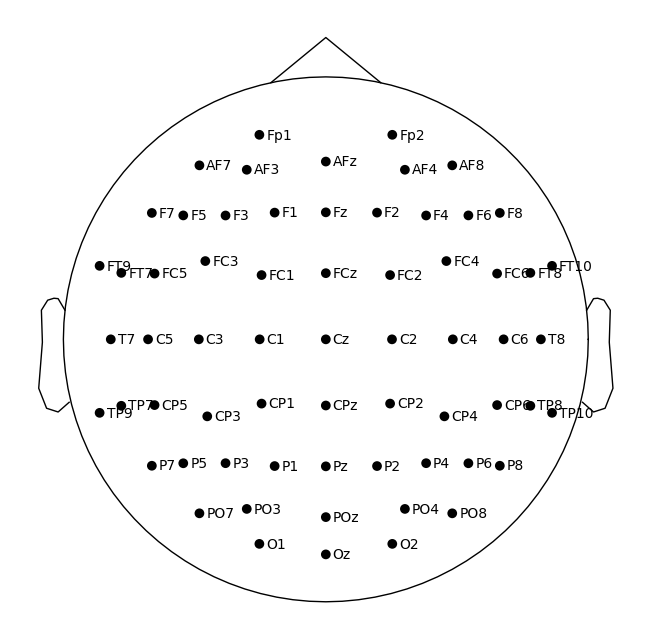

In [9]:
plot=raw_eeg['sub-02'].plot_sensors(show_names=True)

Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


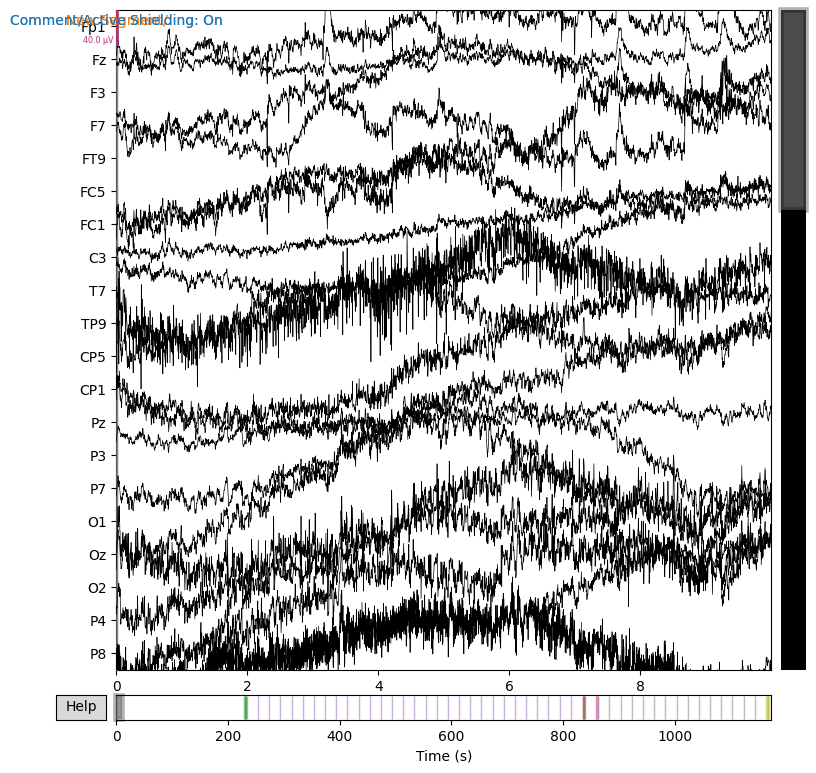

In [10]:
plot=raw_eeg['sub-02'].plot()

# Filtrado de frecuencias

Antes de adentrarnos de lleno en el filtrado de frecuencia, es importante comprender a qué se refiere este concepto básico.

Una frecuencia se puede entender como la cantidad de veces que ocurre un evento específico dentro de un periodo de tiempo predeterminado.

Por ejemplo, 1 Hz hace referencia a que un evento ocurre una vez en un segundo, 10 Hz a diez veces en un segundo, 100 Hz a 100 veces en un segundo, etc.







In [11]:
#@title Ｂｌａｃｋ　ｂｏｘ　（ｓｉｇｎａｌ　ｆｒｅｑｕｅｎｃｉｅｓ）
# Bandas EEG y sus rangos
eeg_bands = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alfa": (8, 13),
    "Beta": (13, 30),
    "Gamma": (30, 100)
}

eeg_colors = {
    "Delta": "#00ffd5",
    "Theta": "#ff00ff",
    "Alfa": "#b6ff00",
    "Beta": "#ff6ec7",
    "Gamma": "#00ffff"
}

def get_band_and_color(freq):
    for name, (low, high) in eeg_bands.items():
        if low <= freq < high:
            return name, eeg_colors[name]
    return "Fuera de rango", "#ffffff"

def plot_senoide(freq, dur):
    fs = 1000
    t = np.arange(0, dur, 1/fs)
    y = np.sin(2 * np.pi * freq * t)

    band_name, color = get_band_and_color(freq)

    fig, ax = plt.subplots(figsize=(8, 3), dpi=150)
    fig.patch.set_facecolor("#0a0f1f")
    ax.set_facecolor("#0a0f1f")

    ax.plot(t, y, linewidth=8, alpha=0.08, color=color)
    ax.plot(t, y, linewidth=2.2, color=color)

    ax.set_xlim(0, dur)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel("Tiempo (s)", color="#cde3ff")
    ax.set_ylabel("Amplitud", color="#cde3ff")
    ax.set_title(
        f"Frecuencia: {freq:.2f} Hz  →  Banda: {band_name}",
        color="#e6f0ff",
        pad=10
    )

    for spine in ax.spines.values():
        spine.set_color("#20345c")
        spine.set_linewidth(1.2)

    ax.tick_params(colors="#a8c8ff")
    ax.grid(True, which="both", linewidth=0.6, alpha=0.25)
    plt.tight_layout()
    plt.show()

# Sliders
freq_slider = ipywidgets.FloatSlider(
    value=10.0, min=0.5, max=50.0, step=0.5,
    description='Frecuencia (Hz):'
)

dur_slider = ipywidgets.FloatSlider(
    value=1.6, min=0.1, max=1.0, step=0.1,
    description='Duración (s):'
)

ipywidgets.interactive(
    plot_senoide,
    freq=freq_slider,
    dur=dur_slider
)

interactive(children=(FloatSlider(value=10.0, description='Frecuencia (Hz):', max=50.0, min=0.5, step=0.5), Fl…

# ¿Qué pasa cuando captamos varios eventos en distintas frecuencias al mismo  tiempo?



<br>

<figure style="text-align:left; margin: 1.25rem 0;background:#fff;">
  <img src="https://raw.githubusercontent.com/neuropucp/neuroling-workshop/refs/heads/main/res/assets/02.png"
       alt="montaje"
       style="display:block; margin:0 auto; max-width:100%; width:1080px; height:auto;">
  <figcaption style="margin-top:.5rem; color:#555;">Frecuencias de actividad cerebral.</figcaption>
</figure>

<br>

<br>

<figure style="text-align:left; margin: 1.25rem 0;background:#fff;">
  <img src="https://raw.githubusercontent.com/neuropucp/neuroling-workshop/refs/heads/main/res/assets/01.png"
       alt="montaje"
       style="display:block; margin:0 auto; max-width:80%; width:600px; height:auto;">
  <figcaption style="margin-top:.5rem; color:#555;">Frecuencias juntas.</figcaption>
</figure>


<br>

Las frecuencias que puede captar el EEG no solamente son del cerebro, sino también de la electricidad del aparato mismo o artefactos creados por movimientos del participante. Por eso es necesario filtrarlas. En este caso, le aplicaremos un filtrado estándar en análisis de neurociencia.

El filtrado es:
- Bandpass entre 0.1-40 Hz (Esto hace que sólo se mantengan las frecuencias arriba de 0.1 y 40 Hz).

- Filtros notch (de frecuencia específica) en 50 y 60 Hz.



<br>




<table>
  <tr><th colspan="2" align="left">Método: <strong>.filter
  <br><br>
  Objeto mne.io.Raw
  
  </strong>
      <a href="https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.filter"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      [docs]
  </a>

  
  </th></tr>





<tr><th colspan="1">Parámetros</th><th colspan="1" align="left">Descripción</th></tr>
<tr><td>l_freq</td><td>Frecuencia que estará en el límite inferior. Sólo pasarán las frecuencias más altas que esta. En nuestro caso: 0.1. </td></tr>
<tr><td>h_freq</td><td>Frecuencia que estará en el límite superior. Sólo pasarán las frecuencias más bajas que esta. En nuestro caso: 40. </td></tr>
<tr><th colspan="2" align="left">Objetos que retorna:</th></tr>

<td colspan="2">
El mismo objeto con el paso de banda aplicado. Sólo pasan las frecuencias entre 0.1 y 40 Hz.
</table>

<br>

<table>
  <tr><th colspan="2" align="left">Método: <strong>.notch_filter</strong>
<br><br> Objeto mne.io.Raw</strong>
  </strong>
      <a href="https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.notch_filter"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      [docs]
  </a>

  
  </th></tr>


<tr><td>freqs</td><td>Frecuencia o frecuencias que queremos filtrar. Si ponemos una lista, tendrá que ser entre paréntesis. Utilizaremos (50,60) para filtrar 50Hz y 60Hz. </td></tr>


<tr><th colspan="2" align="left">Objetos que retorna:</th></tr>

<td colspan="2">
Objeto EEG filtrado.
</table>

In [12]:
filtered_eeg={}
for subject, raw in raw_eeg.items():
  eeg=raw.copy()
  eeg=eeg.filter(l_freq=0.1,
             h_freq=40
             )
  eeg=eeg.notch_filter(freqs=(50,60))
filtered_eeg[subject]=eeg

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 8449 samples (33.004 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1691 samples (6.605 s)



## Comparando la señal antes y después del filtrado de paso de banda

=====Señal sin filtrar=====:
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


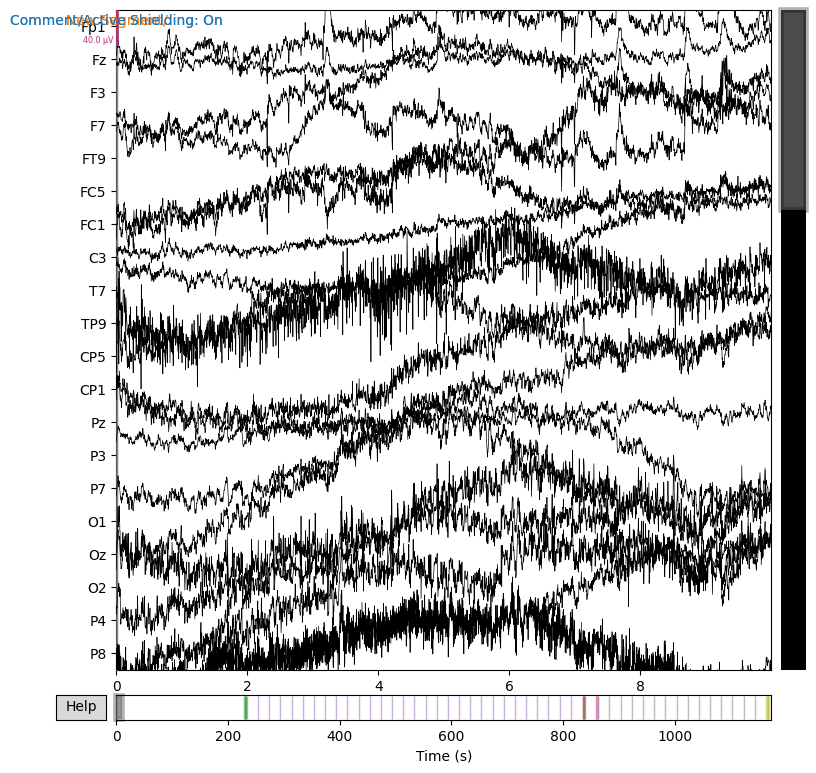

=====Señal filtrada=====:
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


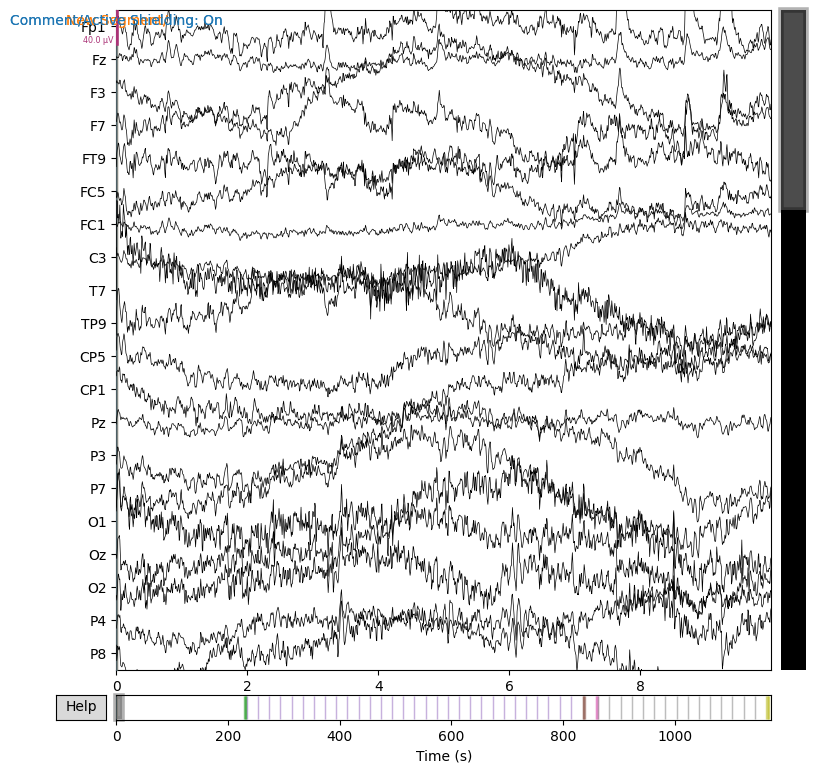

In [13]:
print('=====Señal sin filtrar=====:')
plot1=raw_eeg['sub-02'].plot()
print('=====Señal filtrada=====:')
plot2=filtered_eeg['sub-02'].plot()

# Detectar canales dañados e interpolarlos

¡Muy bien! El siguiente paso es detectar los canales que tienen mucho ruido y son inutilizables y luego interpolarlos para recuperar la señal en ese espacio perdido.

Antes de entender la interpolación, centrémonos en cómo realizaremos el paso de detección de canales dañados.

---

#PyPrep

---

El PyPrep es una librería creada específicamente para detectar canales dañados. Utiliza herramientas como correlación de canales, ruido de alta frecuencia, detección de canales vacíos y RANSAC.

En este caso, utilizaremos esta herramienta para obtener una lista de canales dañados y luego añadirla a la información de nuestro objeto (de python) EEG.


Para esto, el proceso consistirá en definir un objeto con los parámetros de nuestro análisis y luego invocar un método del objeto para aplicar las distintas pruebas de detección de canales dañados.

<br>

<table>
  <tr><th colspan="2" align="left">Función: <strong>pyprep.NoisyChannels</strong>
  
  </strong>
      <a href="https://pyprep.readthedocs.io/en/latest/generated/pyprep.NoisyChannels.html"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      [docs]
  </a>

  
  </th></tr>





<tr><th colspan="1">Parámetros</th><th colspan="1" align="left">Descripción</th></tr>
<tr><td>raw</td><td>Archivo EEG/'Raw' de MNE. PyPrep sólo se puede aplicar a este nivel. </td></tr>
<tr><td>do_detrend</td><td>True or False. PyPrep puede filtrar la señal por nosotros, poniéndole un límite inferior de 1. En este caso, nuestra señal ya está filtrada, así que será False. </td></tr>
<tr><td>random_state</td><td>Métodos internos de PyPrep usan la simulación aleatoria para comparar si los valores se deben al azar. Aquí escogemos un "seed" o dimensión en la que queremos que se ejecute lo aleatorio (7). </td></tr>
<tr><th colspan="2" align="left">Objetos que retorna:</th></tr>

<td colspan="2">
Objeto PyPrep con métodos que pueden aplicarle técnicas de rechazo de electrodos.
</table>

<br>
<br>

<table>
  <tr><th colspan="2" align="left">Método: <strong>.find_all_bads</strong>
<br><br> Objeto pyprep.NoisyChannels</strong>
  </strong>
      <a href="https://pyprep.readthedocs.io/en/latest/generated/pyprep.NoisyChannels.html#pyprep.NoisyChannels.find_all_bads"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      [docs]
  </a>

  
  </th></tr>





<tr><th colspan="1">Parámetros</th><th colspan="1" align="left">Descripción</th></tr>
<tr><td>ransac</td><td>En caso de que no funcione el RANSAC, podemos indicar que no se realice la prueba colocando el parámetro en FALSE. </td></tr>

</table>

<br>

Un detalle importante que debemos tener en cuenta es que el PyPrep está diseñado para ejecutarse en señal sin filtrar, así que obtendremos la lista de electrodos dañados a partir de nuestra señal original y luego esa lista se agregará a la señal filtrada.

In [14]:
#@title Detección y apunte de canales dañados

for subject, eeg in filtered_eeg.items():
  eeg_pyprep=eeg.copy()
  noisy=pyprep.NoisyChannels(
      raw=eeg_pyprep,
      do_detrend=False,
      random_state=7
  )
  noisy.find_all_bads()
  eeg_pyprep.info['bads']=noisy.get_bads() #Guardamos la lista de canales dañados en la información del objeto
  raw_eeg[subject].info['bads']=noisy.get_bads() #Se guarda también en la señal original.
  results=noisy.get_bads(as_dict=True)
  print(f"Resultados de sujeto {subject}:{results}")
  filtered_eeg[subject]=eeg_pyprep

  0%|          |  : 0/234 [00:00<?,       ?it/s]

Resultados de sujeto sub-02:{'bad_by_nan': [], 'bad_by_flat': ['Cz'], 'bad_by_deviation': [], 'bad_by_hf_noise': ['FC3'], 'bad_by_correlation': ['CP1', 'FC3', 'C1', 'PO3'], 'bad_by_SNR': ['FC3'], 'bad_by_dropout': [], 'bad_by_psd': ['PO3'], 'bad_by_ransac': [np.str_('C3'), np.str_('CP5'), np.str_('CP6'), np.str_('CP2'), np.str_('C4'), np.str_('FC2'), np.str_('AFz'), np.str_('C5'), np.str_('CP3'), np.str_('P1'), np.str_('P2'), np.str_('CPz'), np.str_('CP4'), np.str_('C6'), np.str_('C2'), np.str_('FC4'), np.str_('F2')], 'bad_by_manual': [], 'bad_all': [np.str_('FC4'), np.str_('AFz'), np.str_('CP2'), 'CP1', np.str_('C3'), np.str_('C6'), 'Cz', 'PO3', np.str_('C2'), np.str_('C4'), np.str_('C5'), np.str_('F2'), np.str_('CPz'), np.str_('CP3'), 'FC3', np.str_('CP6'), np.str_('P1'), np.str_('CP4'), np.str_('P2'), 'C1', np.str_('FC2'), np.str_('CP5')]}



#¿Qué es interpolar?


<figure style="text-align:left; margin: 1.25rem 0;background:#fff;">
  <img src="https://raw.githubusercontent.com/da-falcon/event_hri/refs/heads/main/resources/01_ai.png"
       alt="montaje"
       style="display:block; margin:0 auto; max-width:100%; width:1080px; height:auto;">
  <figcaption style="margin-top:.5rem; color:#555;">Ilustración de interpolación.</figcaption>
</figure>



<br>

<table>
  <tr><th colspan="2" align="left">Método: <strong>.interpolate_bads</strong>
<br><br> Objeto pyprep.NoisyChannels</strong>
  </strong>
      <a href="https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.interpolate_bads"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      [docs]
  </a>

  
  </th></tr>





<tr><th colspan="1">Parámetros</th><th colspan="1" align="left">Descripción</th></tr>
<tr><td>reset_bads</td><td>Remueve la marca 'bads' de los canales, en la información del objeto. </td></tr>

</table>

<br>

In [15]:
#@title Interpolar electrodos de la señal filtrada

display(filtered_eeg['sub-02'])

for subject, eeg in filtered_eeg.items():
  eeg_int=eeg.copy()
  eeg_int=eeg_int.interpolate_bads(reset_bads=True)
  filtered_eeg[subject]=eeg_int
display(filtered_eeg['sub-02'])

<RawBrainVision | sub-02_task-phoneuse_eeg.eeg, 66 x 300170 (1172.5 s), ~151.2 MiB, data loaded>

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 42 sensor positions
Interpolating 22 sensors


<RawBrainVision | sub-02_task-phoneuse_eeg.eeg, 66 x 300170 (1172.5 s), ~151.2 MiB, data loaded>

# El concepto de referencia

Luego de la interpolación, el paso más común es realizar un análisis de componentes independientes. Sin embargo, antes de explicar ese proceso, se realizará un paréntesis para entender un concepto importante en la medición de EEG: **La referencia**  



<br>

<figure style="text-align:left; margin:0;">
  <img src="https://raw.githubusercontent.com/da-falcon/eeg_lecture/refs/heads/main/resources/reference.png"
       alt="montaje"
       width="600">
  <figcaption style="margin-top:.25rem; color:#555;">Neurocientíficos investigando   〜ｌａ　ｒｏｃａ〜. Medición en curso.</figcaption>
</figure>





# Análisis de Componentes Independientes.

Otra de las técnicas para poder limpiar la señal es el análisis de componentes independientes (ICA). Desde esta perspectiva, se intenta descomponer la señal en fuentes independientes de actividad eléctrica particular, como parpedeos, movimientos musculares, etc.  

Podemos imaginar que, en teoría, la señal entera es el resultado de distintas fuentes independientes mezclándose. Si identificamos las que no pertenecen a actividad cerebral, podemos extraerlas y quedarnos sólo con lo "cerebral" de la señal.

<br>
<br>

<figure style="text-align:left; margin: 1.25rem 0;background:#fff;">
  <img src="https://raw.githubusercontent.com/da-falcon/event_hri/refs/heads/main/resources/02_ai.png"
       alt="montaje"
       style="display:block; margin:0 auto; max-width:100%; width:1080px; height:auto;">
  <figcaption style="margin-top:.5rem; color:#555;">Señal EEG siendo creada. Imagen verídica.</figcaption>
</figure>

<br>

Para realizar el análisis de componentes independientes, usaremos funciones integradas en MNE. Primero crearemos el objeto con los parámetros de nuestro análisis, y luego invocaremos el método del objeto para ajustar el análisis en nuestros datos.


<table>
  <tr><th colspan="2" align="left">Función: <strong>mne.preprocessing.ICA</strong></strong>
  </strong>
      <a href="https://mne.tools/stable/generated/mne.preprocessing.ICA.html"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      [docs]
  </a>

  
  </th></tr>


<tr><td>n_components</td><td>El número de componentes que queremos que estime. Aquí es donde va el número del rank. </td></tr>
<tr><td>method</td><td>Método para realizar la computación. Elegiremos 'infomax'. </td></tr>
<tr><td>fit_params</td><td>Diccionario que indica los parámetros adicionales del método. {'extended':True} para infomax extendido. </td></tr>
<tr><td>max_iter</td><td>Controla el número de iteraciones para el cálculo. 'auto' para que la función decida por sí sola. </td></tr>
<tr><td>random_state</td><td>Seed para replicabilidad. Universo 7. </td></tr>

<tr><th colspan="2" align="left">Objetos que retorna:</th></tr>

<td colspan="2">
Objecto ICA con los parámetros que definimos. Listo para entrenarse con una señal.
</table>


<br>


<br>


<table>
  <tr><th colspan="2" align="left">Método: <strong>.fit</strong></strong>
  </strong>
  <br><br>
  Objeto mne.preprocessing.ICA</strong>
  </strong>
      <a href="https://mne.tools/stable/generated/mne.preprocessing.ICA.html#mne.preprocessing.ICA.fit"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      [docs]
  </a>

  
  </th></tr>


<tr><td>inst</td><td>La data eeg que se quiere para entrenar el ICA y dibujar los "mapas". </td></tr>
<tr><td>picks</td><td>Tipo de canales que se quieren considerar para construir los mapas ICA. Por default canales que tienen señal cerebral ('eeg' o 'meg' por ejemplo). Es buena práctica siempre delimitarlo de forma explícita ('eeg' en nuestro caso). </td></tr>

<tr><th colspan="2" align="left">Objetos que retorna:</th></tr>

<td colspan="2">
Objecto ICA con el mapa de transformación y destransformación.

</table>

# Identificación de componentes artefactuales e ICLabel

Luego de haber realizado el análisis de componentes independientes, existe la tarea de encontrar qué componentes descartar o no. Algunos pueden pertenecer a ruido ocultar, otros a ruido eléctrico, etc.

Para esto, utilizaremos dos métodos simples. El primero, es un método integrado de MNE, del objeto que retorna el análisis de componentes principales. Este método nos permite identificar componentes que pertenecen a ruido ocular en base al parecido que tienen a electrodos que elijamos. Los electrodos elegidos serán los frontales, ya que estos también pueden capturar actividad ocular de manera bastante específica.


<br>
<table>
  <tr><th colspan="2" align="left">Método: <strong>.find_bads_eog</strong>
  <br><br>
  Objeto mne.preprocessing.ICA</strong>
  </strong>
      <a href="https://mne.tools/stable/generated/mne.preprocessing.ICA.html#mne.preprocessing.ICA.find_bads_eog"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      [docs]
  </a>
  
  </th></tr>
  <tr><th colspan="1">Parámetros</th><th colspan="1" align="left">Descripción</th></tr>
  <tr><td>inst(objeto con señal)</td><td>La señal sobre la cual queremos que se compute el método.</td></tr>
  <tr><td>ch_name</td><td>El nombre de los canales para utilizar como "EOG" en el cálculo. En este caso "VEOG" y "HEOG".</td></tr>
  <tr><td>threshold</td><td>Umbral por sobre el cual el componente es clasificado como valor extremo o no (outlier, anómalo). </td></tr>
  <tr><td>verbose</td><td>Controla si queremos datos del estado del proceso. Por default True, pero para outputs más legibles lo setearemos en False. </td></tr>
  <tr><th colspan="2" align="left">Objetos que retorna:</th></tr>

  <td colspan="2">
  Dos diccionarios, uno con el índice de los objetos detectados como pertenecientes a artefactos, y otro con el índice de correlación de todos los componentes.
</table>

<br>
<br>

Otra herramienta que se utilizará para identificar componentes artefactuales es un algoritmo entrenado que se llama ICLabel, que identificará los componentes de manera automática. En este caso, el ICLabel proviene de una librería adicional a MNE, pero integrada a él. La razón detrás de ello es que la librería pertenece a un proyecto independiente de desarrollo de algoritmos de identificación de componentes artefactuales.

<br>

<table>
  <tr><th colspan="2" align="left">Función: <strong>mne_icalabel.label_components
  </strong>
      <a href="https://mne.tools/mne-icalabel/stable/generated/api/mne_icalabel.label_components.html#mne_icalabel.label_components"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      [docs]
    </a>
  </th>
  </tr>

  <tr><th colspan="1">Parámetros</th><th colspan="1" align="left">Descripción</th></tr>
  <tr><td>inst(objeto con señal)</td><td>La señal sobre la cual queremos que se proyecte el mapa ica en la función.</td></tr>
  <tr><td>ica (objeto ica)</td><td>La solución ica (mapa) que queremos utilizar para etiquetar.</td></tr>
  <tr><td>method</td><td>Método para etiquetar. Puede ser "icalabel" o "megnet" (para datos MEG usando redes neuronales). </td></tr>
  <tr><th colspan="1">Objetos que retorna la función</th><th colspan="1" align="left">Descripción</th></tr>
  <tr><td>component_dict</td><td>Diccionario con las llaves "y_pred_probs" para acceder a los valores de probabilidades y la clave "labels" para acceder a los valores de las etiquetas.</td></tr>
</table>

In [16]:
iclabel_eeg={}
for subject, eeg in filtered_eeg.items():
  destiny_eeg=eeg.copy()
  destiny_eeg=destiny_eeg.set_eeg_reference('average', ch_type='eeg')

  train_eeg=raw_eeg[subject].copy()
  train_eeg=train_eeg.filter(l_freq=1,
                             h_freq=100)
  train_eeg=train_eeg.notch_filter(freqs=(50, 60))
  train_eeg=train_eeg.interpolate_bads(reset_bads=True)
  train_eeg=train_eeg.set_eeg_reference('average', ch_type='eeg')

  ica = mne.preprocessing.ICA(
              n_components=0.999999, #Rank o dimensiones independientes.
              method = "infomax",  # Método a elegir.
              fit_params = {'extended':True}, #Parámetros del método, hay "infomax" e "infomax extended". Queremos el extended.
              max_iter = "auto",  # Maximum number of iterations; typically should be higher, like 500 or 1000
              random_state = 7  # Lucky!
          )

  ica.fit(train_eeg, picks='eeg')

  eog_indices, eog_scores = ica.find_bads_eog( #Este es el método.
    train_eeg, #pasamos nuestro set de entrenamiento
    ch_name=['Fp1', 'Fp2'],
    threshold=3.0,
    verbose=False
    )

  ic_labels = label_components(train_eeg, ica, method="iclabel")
  labels = ic_labels["labels"]
  probs = ic_labels["y_pred_proba"]

  exclude_idx = [
      idx for idx, (label, prob) in enumerate(zip(labels, probs))
      if label not in ["brain", "other"] and prob > 0.9
  ]

  ica.exclude = exclude_idx

  ica.exclude = list(set(ica.exclude + eog_indices))

  eeg_clean = ica.apply(destiny_eeg.copy())
  iclabel_eeg[subject]=eeg_clean

Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 845 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 

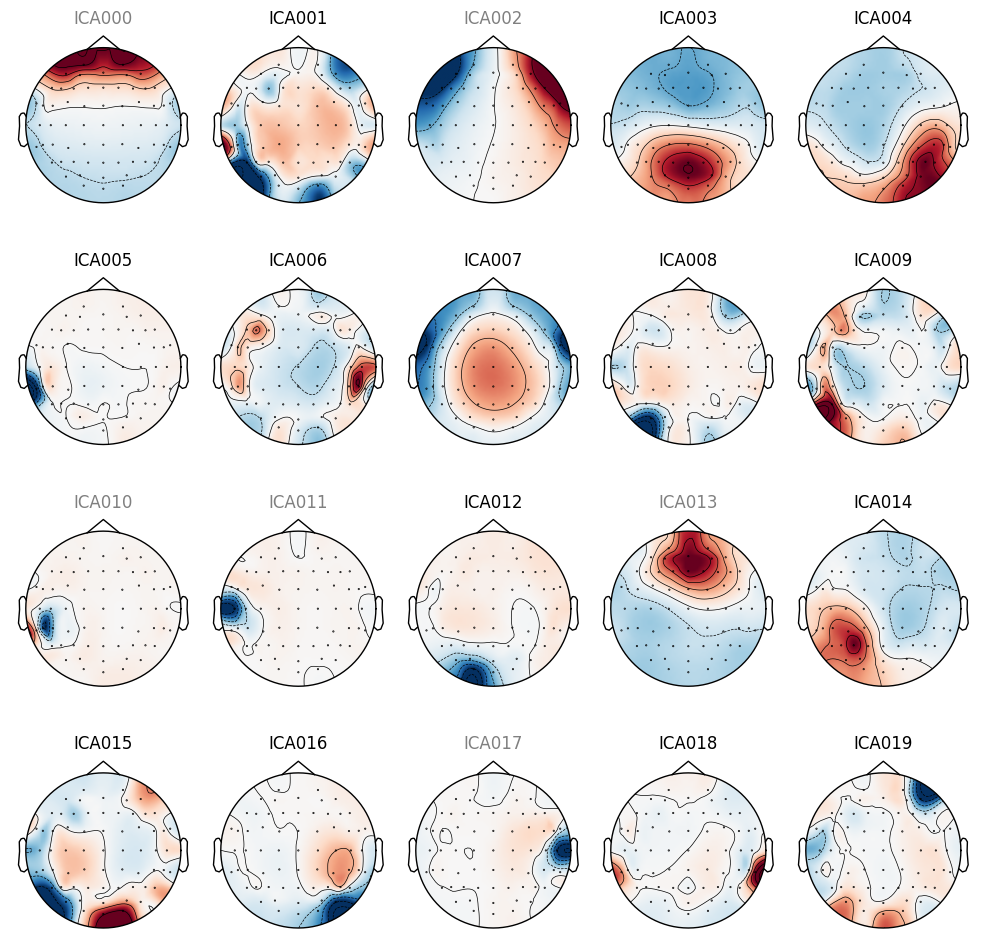

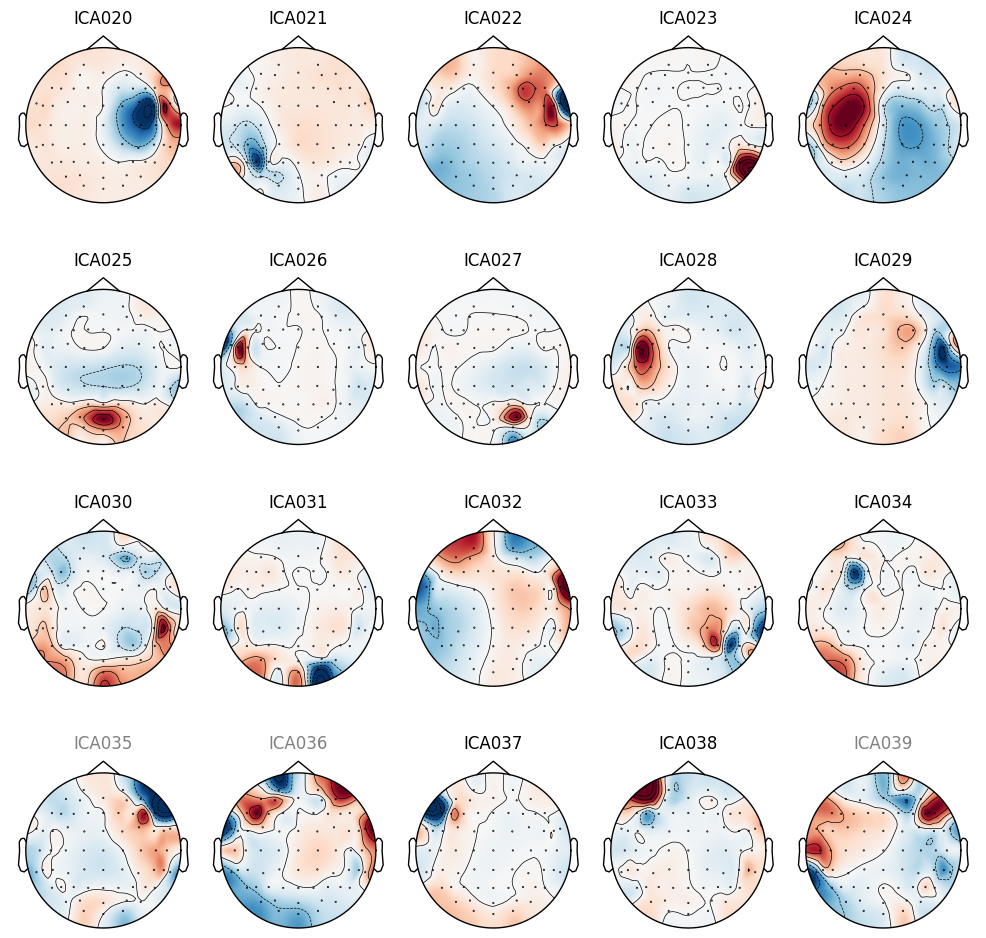

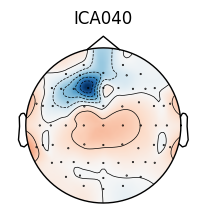

[<MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 195x260.5 with 1 Axes>]

In [17]:
ica.plot_components()

# Epochs: Cortar la señal.

Después de haber pre procesado la señal EEG entera, podemos pasar a la etapa clave de dividir fragmentos de la señal que nos interesan, según nuestro diseño experimental.


Si revisamos la página de la base de datos en Open Neuro para obtener más información del experimento, podemos observar que hay dos estímulos de interés, alrededor de los cuales se han codificado eventos.

---

*EEG event markers are defined for two conditions:*

*Smartphone Monitor (**onset: S 12**; **offset: S 13**)*

*Video Monitor (**onset: S 22**; **offset: S 23**).*

---


Estos eventos están guardados en el objeto que hemos estado pre procesando. Sólo hace falta recuperarlo con un par de métodos integrados.

# Estructura de los eventos

In [18]:
#@title Recuperar eventos del objeto

events, event_id = mne.events_from_annotations(iclabel_eeg['sub-02'])

print(events)
print(event_id)

Used Annotations descriptions: ['Comment/Active Shielding: On', 'New Segment/', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 21', 'Stimulus/S 22', 'Stimulus/S 23']
[[     0      0  99999]
 [     0      0  10001]
 [     0      0  99999]
 [     0      0  10001]
 [ 58581      0     11]
 [ 58581      0     11]
 [ 58838      0     11]
 [ 58838      0     11]
 [ 59094      0     11]
 [ 59094      0     11]
 [ 59350      0     11]
 [ 59350      0     11]
 [ 59606      0     11]
 [ 59606      0     11]
 [ 59862      0     12]
 [ 59862      0     12]
 [ 64977      0     12]
 [ 64977      0     12]
 [ 70096      0     12]
 [ 70096      0     12]
 [ 75215      0     12]
 [ 75215      0     12]
 [ 80335      0     12]
 [ 80335      0     12]
 [ 85454      0     12]
 [ 85454      0     12]
 [ 90573      0     12]
 [ 90573      0     12]
 [ 95693      0     12]
 [ 95693      0     12]
 [100812      0     12]
 [100812      0     12]
 [105931      0     12]
 [105931      0     12]
 [

Estos eventos son como marcas que estarán en nuestra señal, indicando los lugares en donde hacer los recortes

# Recortar la señal guiándonos de los eventos

Luego de haber recuperado los eventos, podemos utilizar la función para hacer Epochs de MNE, el cual cortará la señal tomando los eventos como referencia.

Los eventos son el tiempo 0, y usando esta referencia podemos indicar desde dónde hasta dónde queremos el corte.

Para esto, utilizaremos la función de MNE para realizar epochs (cortes en la señal), que nos permitirá personalizar distintos parámetros de esos cortes.

<br>

<figure style="text-align:left; margin:0;">
  <img src="https://raw.githubusercontent.com/neuropucp/neuroling-workshop/refs/heads/main/res/assets/05_ai.png"
       alt="montaje"
       width="400">
  <figcaption style="margin-top:.25rem; color:#555;">Ejemplo fiel de científicos haciendo epochs.</figcaption>
</figure>





<br>

<table>
  <tr><th colspan="2" align="left">Función: <strong>mne.Epochs</strong></strong>
  </strong></strong>
  </strong>
      <a href="https://mne.tools/stable/generated/mne.Epochs.html"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      [docs]
  </a>

  
  </th></tr>

<br>
<tr><td>raw</td><td>El archivo de la señal continua. En este caso, está dentro de nuestros diccionarios. </td></tr>
<tr><td>events</td><td>Nuestro array de eventos con forma [1,0,1]. </td></tr>
<tr><td>events_id</td><td>Diccionario donde las keys son strings y los values event codes. </td></tr>
<tr><td>tmin</td><td>Si el evento es el tiempo 0, el "tmin" es el tiempo antes del 0. Marcamos el inicio del corte (normalmente es negativo). </td></tr>
<tr><td>tmax</td><td>Marcamos el fin del corte. </td></tr>
<tr><td>baseline</td><td>Se usa para aplicar una línea base. Por default la aplica, podemos decirle "None" para que no lo haga. Aunque aún no sabemos qué es la baseline... </td></tr>
<tr><td>preload</td><td>Cargar el objeto en la memoria RAM. "True" porque queremos hacer operaciones con los epochs. </td></tr>
<tr><th colspan="2" align="left">Objetos que retorna:</th></tr>

<td colspan="2">
Objeto nuevo mne.Epochs.
</table>

In [19]:
epochs=mne.Epochs(
    iclabel_eeg['sub-02'],
    events=events,
    tmin=-0.2,
    tmax=1,
    event_id=event_id,
    event_repeated='drop',
    #reject=dict(eeg=100e-6) #Woah! Parámetro fantasma. Luego veremos a qué alude.
    preload=True
)

Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
66 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 66 events and 308 original time points ...
1 bad epochs dropped


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


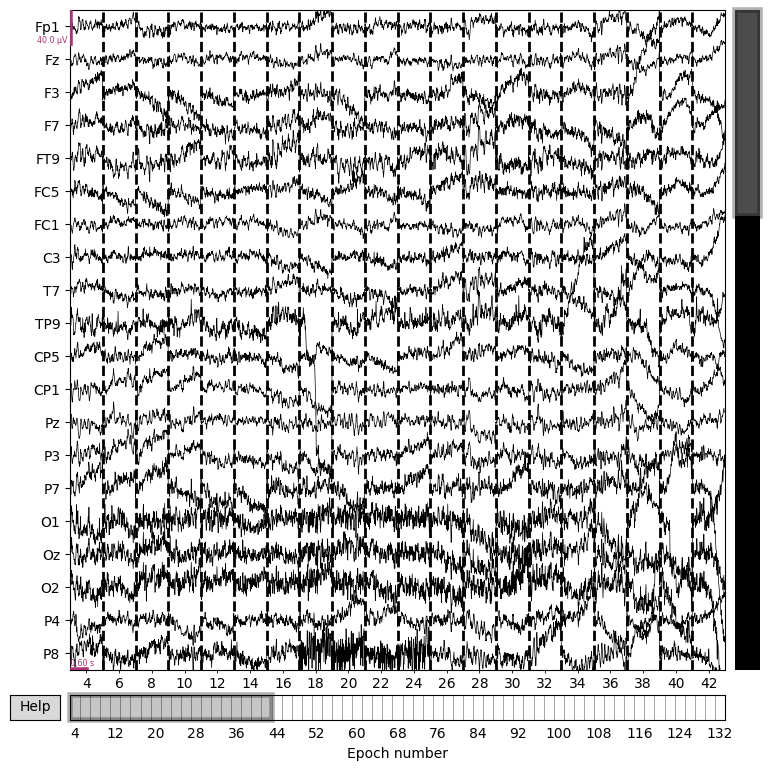

In [20]:
#@title Visualizando los cortes

test1=epochs.plot()

# Autoreject

<br>

Cada decisión dentro el flujo de análisis puede cambiar la señal, así que podríamos decir que antes de obtener un plot o hacer estadística con los voltajes, seguimos procesando.

<br>

A nivel de épocas, también podemos limpiar la señal de artefactos. **Autoreject** es una herramienta integrada, de manera similar a ICLabel, al entorno de MNE. Su implementación generalmente es más fácil que el ICA, así que no demoraremos mucho en implementarla.

<br>

Lo que hace **Autoreject**, a grandes rasgos, es detectar epochs dañados en base a la amplitud o frecuencia de la señal. Internamente, usa métodos aleatorios para simular cómo sería una epoch "normal" con los datos que tenemos para tener un punto de comparación.

<br>

Además del rechazo, **Autoreject** puede rescatar las epochs dañadas con métodos como la **interpolación**, la cual consiste en reconstruir la señal de un canal en base a los canales cercanos. Antes de descartar una epoch, **Autoreject** siempre intenta rescatarla antes con la interpolación.

<br>

**Autoreject** está diseñado para sólo ser implementado sobre objetos mne.Epochs, en contraste al **ICA**, que puede ser utilizado en señales continuas o epocalizadas. Con todo lo que tenemos, estamos listos para pasar nuestras epochs tal y como están a **Autoreject**

<br>


<table>
  <tr><th colspan="2" align="left">Función: <strong>autoreject.Autoreject</strong>
  
  </strong>
      <a href="https://autoreject.github.io/stable/generated/autoreject.AutoReject.html#autoreject.AutoReject"
       target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">
      [docs]
  </a>

  
  </th></tr>





  <tr><th colspan="1">Parámetros</th><th colspan="1" align="left">Descripción</th></tr>
  <tr><td>n_interpolate</td><td>Cuántos canales usar para la interpolación. Usaremos [1,2,3,4] para que pruebe interpolar con 1, 2, 3 o 4 canales.</td></tr>
  <tr><td>random_state</td><td>El seed de aleatoriedad. 7 para la suerte.</td></tr>
  <tr><td>n_jobs</td><td>Núcleos para procesar en paralelo en la CPU. Para replicabilidad, no usamos procesamiento en paralelo.</td></tr>
  <tr><td>thresh_method</td><td>El método que queremos que use autoreject para calcular los umbrales de rechazo de las epochs "bayesian_optimization" por default. </td></tr>
  <tr><td>verbose</td><td>True or False. Determina si queremos que nos de outputs del progreso de la operación.</td></tr>
  <tr><th colspan="2" align="left">Objetos que retorna:</th></tr>

  <td colspan="2">
  Objeto tipo autoreject.Autoreject.
  </td>
</table>

In [21]:
#@title Black Box — (ｒｅｍｅｍｂｅｒ)
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets

eeg_bands = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alfa":  (8, 13),
    "Beta":  (13, 30),
    "Gamma": (30, 100),
}

eeg_colors = {
    "Delta": "#00ffd5", "Theta": "#ff00ff", "Alfa": "#b6ff00",
    "Beta":  "#ff6ec7", "Gamma": "#00ffff",
}

ESCALA_MAX = 220  # µV — fixed scale


def get_band(freq):
    for name, (low, high) in eeg_bands.items():
        if low <= freq < high:
            return name
    return None


def plot_senoide(freq, amp, dur, autoescala):
    fs = 1000
    t = np.arange(0, dur, 1/fs)
    y = amp * np.sin(2 * np.pi * freq * t)

    band = get_band(freq)
    color = eeg_colors.get(band, "#ffffff")

    fig, ax = plt.subplots(figsize=(9, 3.4), dpi=150)
    fig.patch.set_facecolor("#0a0f1f")
    ax.set_facecolor("#0a0f1f")

    # space before 0
    margen = dur * 0.05
    ax.set_xlim(-margen, dur)

    # content
    ax.axhspan(0, amp, color=color, alpha=0.09)
    ax.axhline(amp, ls="--", lw=1.2, color=color, alpha=0.75)
    ax.axhline(-amp, ls=":",  lw=1.0, color=color, alpha=0.30)
    ax.axhline(0, color="#e6f0ff", lw=1.6, alpha=0.85)

    ax.plot(t, y, linewidth=8, alpha=0.08, color=color)
    ax.plot(t, y, linewidth=2.2, color=color)

    # arrow
    x0 = -margen * 0.55
    ax.annotate("", xy=(x0, amp), xytext=(x0, 0),
                arrowprops=dict(arrowstyle="-|>", color="#e6f0ff", lw=1.8,
                                mutation_scale=14))
    ax.plot([x0], [0], marker="o", ms=4, color="#e6f0ff")

    ax.text(0.985, 0.95, f"Amplitud = {amp:.1f} µV  ({2*amp:.1f} µV peak-to-peak)",
            transform=ax.transAxes, color="#e6f0ff", fontsize=8.5,
            ha="right", va="top",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="#0a0f1f",
                      edgecolor="#20345c", linewidth=1.0))

    if autoescala:
        ax.set_ylim(-amp * 1.35, amp * 1.35)
    else:
        ax.set_ylim(-ESCALA_MAX, ESCALA_MAX)

    ax.set_xlabel("Tiempo (s)", color="#cde3ff")
    ax.set_ylabel("Amplitud (µV)", color="#cde3ff")

    sub = band if band else "Fuera de rango EEG"
    ax.set_title(f"{freq:.2f} Hz →  {sub}  ·  {amp:.1f} µV",
                 color="#e6f0ff", pad=10)

    for spine in ax.spines.values():
        spine.set_color("#20345c"); spine.set_linewidth(1.2)
    ax.tick_params(colors="#a8c8ff")
    ax.grid(True, linewidth=0.6, alpha=0.20)
    plt.tight_layout()
    plt.show()


ipywidgets.interactive(
    plot_senoide,
    freq=ipywidgets.FloatSlider(value=10.0, min=0.5, max=50.0, step=0.5,
                                description='Frecuencia (Hz):',
                                style={'description_width': 'initial'},
                                continuous_update=False),
    amp=ipywidgets.FloatSlider(value=30.0, min=0.5, max=200.0, step=0.5,
                               description='Amplitud (µV):',
                               style={'description_width': 'initial'},
                               continuous_update=False),
    dur=ipywidgets.FloatSlider(value=1.6, min=0.1, max=2.0, step=0.1,
                               description='Duración (s):',
                               style={'description_width': 'initial'},
                               continuous_update=False),
    autoescala=ipywidgets.Checkbox(value=False, description='Autoescala Y'),
)

interactive(children=(FloatSlider(value=10.0, continuous_update=False, description='Frecuencia (Hz):', max=50.…

In [22]:


ar = autoreject.AutoReject(
n_interpolate=[1, 2, 3, 4], #recommended in the documentation
random_state=7, #Universo 7
n_jobs=1, ### Esto es recomendado para la replicabilidad, por el parallel processing.
verbose=False,
thresh_method="bayesian_optimization")


epochs_enhanced, reject_log = ar.fit_transform(epochs, return_log=True)




Dropped 30 epochs: 12, 16, 17, 19, 20, 23, 25, 26, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 52, 56, 57, 60, 61, 62, 64


Luego de filtradas las epochs, un último paso que se puede dar es aplicar la línea base (Baseline) a cada epoch.

# Pero ¿Qué es la baseline?

In [23]:
#@title Ｂｌａｃｋ　Ｂｏｘ＿(Baselines)


# function to draw signal
def draw_potential(t):
    y = 0.2
    y += 0.6 * np.exp(-((t + 0.3) ** 3) / (2 * 0.1 ** 3))   # before 0
    y += -0.8 * np.exp(-((t - 0.3) ** 2) / (2 * 0.08 ** 2)) # after 0
    return y

# function to draw correction. Takes the previous funct
def plot_potential(b_ini, apply_baseline):
    fs = 1000
    t = np.linspace(-0.4, 0.8, int(1.2 * fs))
    y_orig = draw_potential(t)
    y_corr = y_orig.copy()

    # b_ini should be <= 0
    b_ini = -b_ini
    b_ini = min(b_ini, 0)
    mask = (t >= b_ini / 1000) & (t < 0)
    baseline_mean = np.mean(y_corr[mask]) if np.any(mask) else 0.0
    print(f"Promedio de la señal del baseline ({b_ini} a 0 ms): {baseline_mean:.4f} µV")
    if apply_baseline:
        if np.any(mask):
            y_corr -= baseline_mean

    # Select which plot to show
    y_to_plot = y_corr if apply_baseline else y_orig

    # Plot
    fig, ax = plt.subplots(figsize=(8, 3), dpi=150)
    fig.patch.set_facecolor("#0a0f1f")
    ax.set_facecolor("#0a0f1f")

    # Remnant of original signal
    if apply_baseline:
        ax.plot(t * 1000, y_orig, linewidth=1.5, color="#00ffd5", alpha=0.2, label="Original")

    # Actual signal
    ax.plot(t * 1000, y_to_plot, linewidth=2.2, color="#00ffd5", label="Corregida" if apply_baseline else "Original")

    ax.axvline(0, color="#ff6ec7", linestyle="--", linewidth=1)
    ax.axvspan(b_ini, 0, color="#ff6ec7", alpha=0.1)

    ax.set_xlim(-400, 800)
    ax.set_ylim(-1, 1)
    ax.set_xlabel("Tiempo (ms)", color="#cde3ff")
    ax.set_ylabel("Amplitud (µV)", color="#cde3ff")
    ax.set_title(
        f"Señal {'con' if apply_baseline else 'sin'} {f'baseline de {baseline_mean:.2f}µV ({b_ini} a 0 ms)' if apply_baseline else 'baseline (0.2 µV en tiempo 0)'}",
        color="#e6f0ff", pad=10
    )

    for spine in ax.spines.values():
        spine.set_color("#20345c")
        spine.set_linewidth(1.2)

    ax.tick_params(colors="#a8c8ff")
    ax.grid(True, which="both", linewidth=0.6, alpha=0.25)
    ax.legend(loc="upper right", facecolor="#0a0f1f", edgecolor="#20345c",
              labelcolor="#cde3ff", fontsize=8)

    #box
    if np.any(mask):
      ax.text(
          x=-100,  # center
          y=-0.2,
          s=f"Promedio: {baseline_mean:.3f} µV",
          color="#00ffd5",
          ha="center",
          va="center",
          fontsize=7,
          bbox=dict(facecolor="#0a0f1f", boxstyle="round,pad=0.2")
      )
    plt.tight_layout()
    plt.show()

# Widgets
ini_slider = ipywidgets.IntSlider(
    value=0, min=0, max=400, step=10, description='Baseline (ms)'
)

toggle_baseline = ipywidgets.ToggleButtons(
    options=[("Sin aplicar", False), ("Aplicada", True)],
    description="Corrección:",
)

ipywidgets.interactive(plot_potential, b_ini=ini_slider, apply_baseline=toggle_baseline)

interactive(children=(IntSlider(value=0, description='Baseline (ms)', max=400, step=10), ToggleButtons(descrip…

In [24]:
epochs_enhanced.apply_baseline((0,0.2))

Applying baseline correction (mode: mean)


<Epochs | 35 events (all good), -0.199 – 1 s (baseline 0 – 0.2 s), ~5.5 MiB, data loaded,
 'New Segment/': 0
 'Stimulus/S 11': 5
 'Stimulus/S 12': 22
 'Stimulus/S 13': 0
 'Stimulus/S 21': 0
 'Stimulus/S 22': 7
 'Stimulus/S 23': 1>

# Respuestas evocadas (Evoking)

Se ha obtenido entonces un corte por cada marcador de evento. En un contexto experimental, una variable de interés suele tener bastantes repeticiones (que se traducen en eventos) para poder cerciorarnos de medirla correctamente.

Esto lleva a que, en nuestro caso, tengamos varios eventos por todas las veces que el participante empezó y terminó a ver la pantalla de video o el smartphone.

Para darnos una idea de lo que ocurre, de forma general, cuando el participante ve la pantalla de video, lo que se hará es promediar todas las veces que empezó a verla. Lo mismo con el smartphone.

Esto nos permite tener, en la jerga del eeg, potenciales "evocados" por el evento.

<figure style="text-align:left; margin:0;">
  <img src="https://raw.githubusercontent.com/neuropucp/neuroling-workshop/refs/heads/main/res/assets/07_ai.png"
       alt="montaje"
       width="400">
  <figcaption style="margin-top:.25rem; color:#555;">Científicos cognitivos creando objetos Evoked. Material real.</figcaption>
</figure>


#Potenciales relacionados a eventos

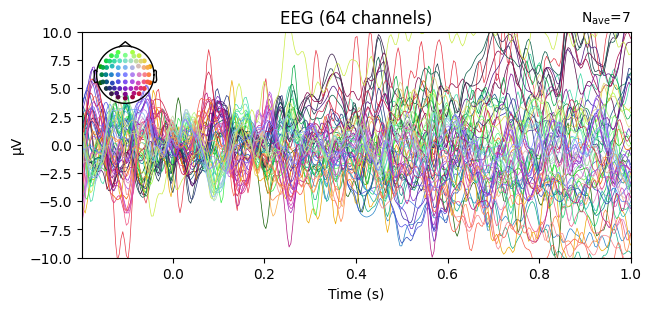

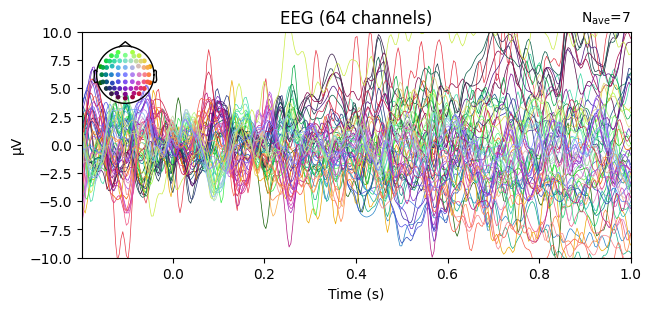

In [25]:
evoked_video_monitor=epochs_enhanced['Stimulus/S 22'].average() # Pantalla de video
evoked_video_monitor.plot(ylim=dict(eeg=[-10, 10]))

Es difícil poder ver qué ocurre cuando se tienen todos los electrodos en un gráfico, pero felizmente se pueden indicar qué electrodos específicos visualizar.

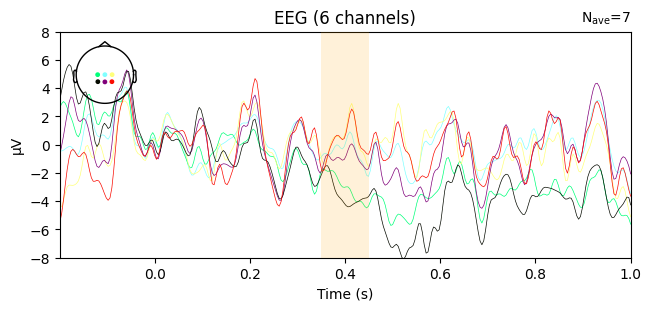

In [26]:
roi=['Cz','C1','C2','CPz', 'CP1', 'CP2']
plot1=evoked_video_monitor.plot(picks=roi,highlight=[0.350, 0.450],
                                ylim=dict(eeg=[-8, 8])
                                )

Sólo de manera ilustrativa, se hará lo mismo con la condición del smartphone, para ver cómo difiere la actividad eléctrica entre condiciones.

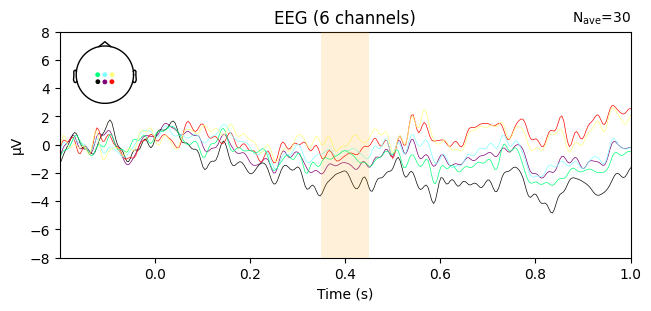

In [27]:
roi=['CPz','CP1','CP2','Cz','C1','C2']
evoked_smart_monitor=epochs['Stimulus/S 12'].average() #pantalla de smartphone
plot2=evoked_smart_monitor.plot(picks=roi,highlight=[0.350, 0.450],
                                ylim=dict(eeg=[-8, 8])
                                )

¿Habrá algún indicio de potencial visual?

Need more than one channel to make topography for eeg. Disabling interactivity.


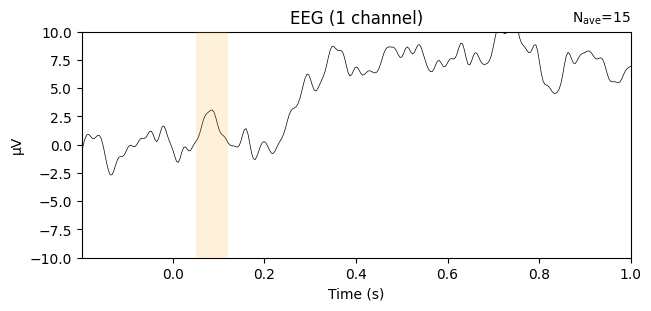

In [28]:
roi=['Oz']
evoked_visual_vmonitor=epochs['Stimulus/S 22'].average()
plot_v1=evoked_visual_vmonitor.plot(picks=roi,highlight=[0.05, 0.12],
                                    ylim=dict(eeg=[-10, 10])
                                    )

Need more than one channel to make topography for eeg. Disabling interactivity.


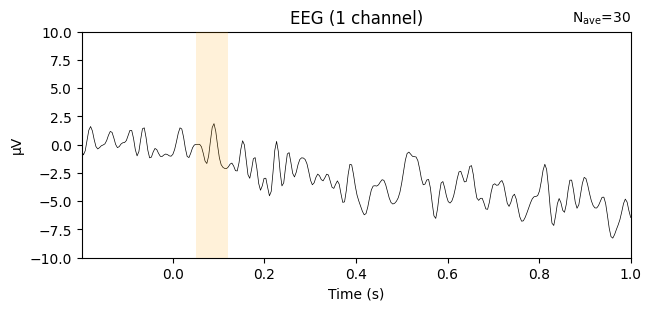

In [29]:
roi=['Oz']
evoked_visual_smonitor=epochs['Stimulus/S 12'].average()
plot_v2=evoked_visual_smonitor.plot(picks=roi,highlight=[0.05, 0.12],
                                    ylim=dict(eeg=[-10, 10])
                                    )

#Explorando

¿Qué otros métodos pueden tener los objetos que hemos creado (<a href="https://mne.tools/stable/generated/mne.Evoked.html"
  target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">evokeds</a>)?

In [30]:
#@title Ｂｌａｃｋ　Ｂｏｘ (＞Ｅｘｐｌｏｒｅ)
def plot_topomap(condition, times, average):
    obj = epochs_enhanced[condition].average()
    obj.plot_topomap(
        times=times,
        average=average,
        ch_type='eeg',
        size=4,
        #res=128,
        #vlim=(-2,2)
        )
toggle_condition=ipywidgets.ToggleButtons(
    options=['Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 22', 'Stimulus/S 23'],
    description='Condición:',
    disabled=False,
    button_style='',
    style={'button_width':'10em'},
)
label = ipywidgets.HTML(
    value="<div style='font-size:18px; text-align:left;'>Exploremos qué sucede en cada condición:</div>"
)
ini_slider = ipywidgets.FloatSlider(
    value=0, min=0, max=1, step=0.05, description='Tiempo (ms)'
)

ave_slider = ipywidgets.FloatSlider(
    value=0.1, min=0.01, max=1, step=0.05, description='Umbral (ms)'
)

plot_widget = ipywidgets.interactive(
    plot_topomap,
    condition=toggle_condition,
    times=ini_slider,
    average=ave_slider
)

ipywidgets.VBox([label, plot_widget])

# Análisis de frecuencias

El otro tipo de análisis que se mencionó fue el de frecuencias. Para esto, podemos utilizar la magnitud de "poder espectral". En resumen, podría entenderse de forma muy general como cuánta fuerza tiene una frecuencia específica en un tiempo elegido.

En este caso, con los epochs ya realizados, calcularemos el poder espectral en cada electrodo a partir de cada epoch individual.

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


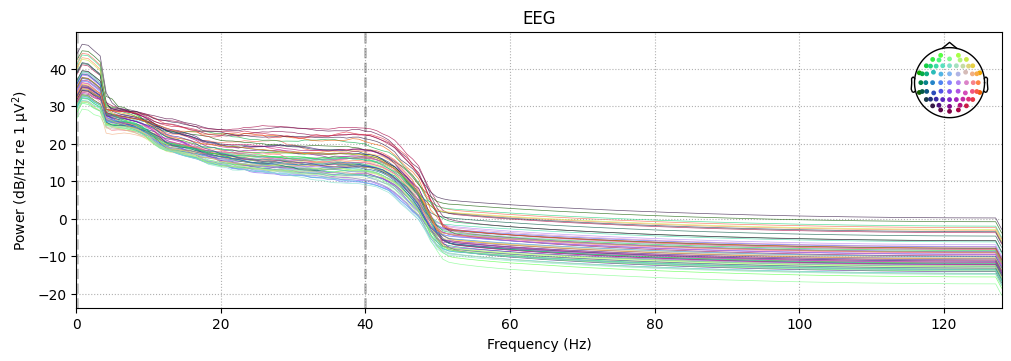

In [31]:
power_video=epochs['Stimulus/S 12'].compute_psd()
test_plot=power_video.plot()

Al calcular el poder espectral, hemos creado un nuevo objeto en donde se encuentra toda esa información {nombre del objeto]. Este es un objeto spectrum, el cual, como buen objeto de Python, tiene distintos métodos. Uno de ellos es `plot_topomap`, el cual nos servirá para obtener una visualización más espacial.



Averaging across epochs before plotting...


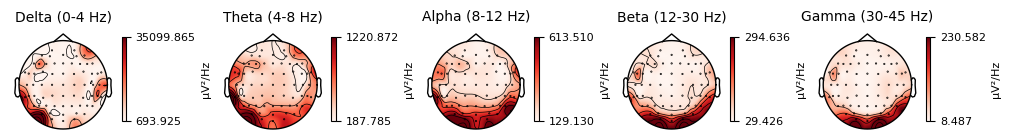

In [32]:
test_plot=power_video.plot_topomap()

¿Qué otros métodos del objeto <a href="https://mne.tools/stable/generated/mne.time_frequency.Spectrum.html"
  target="_blank" rel="noopener" style="margin-left:.5rem; font-weight:normal;">spectrum</a> (que hemos creado para el poder espectral) pueden encontrar?

# Obteniendo los datos

Algunos se habrán dado cuenta de que la información gráfica que hemos obtenido, tanto de los potenciales relacionados a eventos como el análisis de frecuencias, proviene de objetos de Python. Estos objetos, (**evoked para amplitud**, **spectrum para las frecuencias**), también contienen la información numérica para realizar cálculos de contraste de hipótesis y demases.

Basta con usar el método {]

In [33]:
power_video.to_data_frame()

,condition,epoch,freq,Fp1,Fz,F3,F7,FT9,FC5,FC1,...,C6,C2,FC4,FT8,F6,AF8,AF4,F2,FCz,Cz
0,Stimulus/S 12,14,0.000000,4.142889e-11,1.992233e-10,1.835291e-10,3.689442e-10,2.008167e-10,1.128613e-10,3.488075e-10,...,4.620245e-10,7.761193e-11,8.263662e-11,2.220109e-11,1.948855e-10,1.053111e-09,1.121202e-10,1.686568e-10,2.777361e-10,2.388677e-10
1,Stimulus/S 12,14,0.831169,8.510502e-11,3.219177e-10,3.487003e-10,6.067939e-10,3.075075e-10,2.079206e-10,5.980318e-10,...,9.831090e-10,1.564218e-10,1.423125e-10,8.054814e-11,3.834357e-10,2.069843e-09,2.202424e-10,2.730714e-10,4.480768e-10,4.465860e-10
2,Stimulus/S 12,14,1.662338,6.149136e-11,3.007396e-10,3.842591e-10,6.333567e-10,3.634582e-10,2.180415e-10,4.817209e-10,...,8.845950e-10,1.914127e-10,1.523994e-10,1.257022e-10,3.858430e-10,2.073305e-09,2.004452e-10,2.652239e-10,4.471188e-10,4.016187e-10
3,Stimulus/S 12,14,2.493506,7.541193e-11,2.477196e-10,2.503355e-10,5.806524e-10,4.090172e-10,1.979127e-10,4.060063e-10,...,6.918650e-10,1.765513e-10,1.254708e-10,1.357169e-10,3.224741e-10,1.465127e-09,1.910723e-10,2.212793e-10,3.765776e-10,3.538901e-10
4,Stimulus/S 12,14,3.324675,8.880847e-11,2.584706e-10,2.748688e-10,5.110439e-10,4.000581e-10,1.538159e-10,4.184642e-10,...,5.016955e-10,1.820664e-10,1.321042e-10,1.494452e-10,2.527910e-10,1.067332e-09,1.580123e-10,2.320500e-10,3.893697e-10,3.520593e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4645,Stimulus/S 12,72,124.675325,3.114718e-14,3.277257e-14,7.622840e-15,4.539654e-14,3.620370e-14,1.064776e-15,2.425867e-14,...,2.241772e-14,4.318162e-14,6.392609e-14,1.577674e-14,1.209995e-14,8.033012e-15,1.174498e-14,4.490293e-14,2.559835e-14,3.892175e-14
4646,Stimulus/S 12,72,125.506494,3.112193e-14,3.277791e-14,7.617961e-15,4.534496e-14,3.615946e-14,1.057310e-15,2.425698e-14,...,2.238441e-14,4.315835e-14,6.387209e-14,1.581673e-14,1.212737e-14,7.979258e-15,1.177203e-14,4.489864e-14,2.561933e-14,3.893996e-14
4647,Stimulus/S 12,72,126.337662,3.104812e-14,3.273707e-14,7.619756e-15,4.528086e-14,3.609491e-14,1.051038e-15,2.422019e-14,...,2.239348e-14,4.311060e-14,6.383332e-14,1.576951e-14,1.211189e-14,7.991543e-15,1.175053e-14,4.486110e-14,2.559456e-14,3.888544e-14
4648,Stimulus/S 12,72,127.168831,3.105183e-14,3.273301e-14,7.612729e-15,4.526913e-14,3.610657e-14,1.052462e-15,2.421881e-14,...,2.236014e-14,4.308932e-14,6.379884e-14,1.574653e-14,1.210134e-14,7.987577e-15,1.174895e-14,4.485087e-14,2.559266e-14,3.887266e-14


In [34]:
evoked_video_monitor.to_data_frame()

,time,Fp1,Fz,F3,F7,FT9,FC5,FC1,C3,T7,...,C6,C2,FC4,FT8,F6,AF8,AF4,F2,FCz,Cz
0,-0.199219,0.573718,0.602243,-1.002738,1.202925,0.253709,2.789047,1.232378,3.578909,2.068710,...,-2.243103,-4.386441,-1.456113,-0.259470,1.273820,0.219568,1.509879,0.676879,0.816362,-0.395770
1,-0.195312,-0.218359,-0.128770,-1.258791,0.294440,-0.712512,2.560160,0.950389,4.102081,1.687122,...,-1.200569,-4.389812,-1.585475,-0.124034,1.023161,0.065194,0.803684,-0.205579,0.004126,-0.449834
2,-0.191406,-1.008694,-0.832056,-1.847545,-0.071511,-1.210267,1.709815,0.508325,4.220481,0.993315,...,0.026894,-3.954399,-1.477139,-0.329178,0.411539,-0.711387,-0.148117,-0.953671,-0.730592,-0.386583
3,-0.187500,-1.770901,-1.576435,-2.949414,-0.076782,-1.363230,0.382382,-0.178437,3.684494,-0.008945,...,1.158293,-3.389912,-1.436981,-0.386003,-0.478973,-2.091846,-1.193015,-1.634405,-1.414202,-0.286390
4,-0.183594,-2.395707,-2.315599,-4.229608,-0.079429,-1.348908,-0.859132,-0.941451,2.747012,-1.010858,...,1.902823,-2.993754,-1.610929,-0.001257,-1.245296,-3.509348,-1.957278,-2.246209,-2.051695,-0.192325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,0.984375,-2.489503,-2.729150,3.438426,-1.736027,0.527904,-9.692731,-2.261811,-8.458590,5.304857,...,-10.019812,-2.957700,-4.630837,-3.214398,2.711387,9.112771,0.733921,-2.959823,-2.772330,-1.784593
304,0.988281,-2.467656,-2.799091,3.665385,-2.929612,0.751226,-9.597200,-2.357270,-8.102781,5.397311,...,-10.669531,-3.285662,-4.774293,-3.410852,2.273109,8.871144,0.361479,-3.091945,-2.961170,-2.012820
305,0.992188,-2.763513,-3.072999,4.261517,-3.828908,0.727945,-9.444745,-2.522918,-7.704498,5.688121,...,-10.950294,-3.954959,-5.065340,-3.310926,1.799808,8.353031,0.017089,-3.473603,-3.293099,-2.480951
306,0.996094,-3.222369,-3.462422,5.048401,-3.955950,0.462098,-9.406630,-2.733592,-7.607293,6.099458,...,-10.669372,-4.660223,-5.380807,-2.973436,1.529467,7.951889,-0.151693,-3.987788,-3.633962,-3.031071


**Referencias:**


> - Gorgolewski, K. J., Auer, T., Calhoun, V. D., Craddock, R. C., Das, S., Duff, E. P., ... & Poldrack, R. A. (2016). The brain imaging data structure, a format for organizing and describing outputs of neuroimaging experiments. Scientific data, 3(1), 1-9.

> - Gramfort, A., Luessi, M., Larson, E., Engemann, D. A., Strohmeier, D., Brodbeck, C., ... & Hämäläinen, M. (2013). MEG and EEG data analysis with MNE-Python. Frontiers in Neuroinformatics, 7, 267.
[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.17345411.svg)](https://doi.org/10.5281/zenodo.17345411).

>- Prakash Mishra, Tapan K. Gandhi, and Saurabh R. Gandhi (2026). A multimodal dataset of EEG, eye-tracking, and physiological signals during smartphone interaction. OpenNeuro. [Dataset] doi: doi:10.18112/openneuro.ds007537.v2.0.1

> - Jas, M., Engemann, D. A., Bekhti, Y., Raimondo, F., & Gramfort, A. (2017). Autoreject: Automated artifact rejection for MEG and EEG data. NeuroImage, 159, 417-429.

> - Jas, M., Engemann, D., Raimondo, F., Bekhti, Y., & Gramfort, A. (2016, June). Automated rejection and repair of bad trials in MEG/EEG. In 2016 international workshop on pattern recognition in neuroimaging (PRNI) (pp. 1-4). IEEE.

> - Appelhoff, S., Hurst, A. J., Lawrence, A., Li, A., Mantilla Ramos, Y. J., O'Reilly, C., ... & Dancker, J. (2022). PyPREP: A Python implementation of the preprocessing pipeline (PREP) for EEG data. Zenodo, 2. [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.16039994.svg)](https://doi.org/10.5281/zenodo.16039994)

> - Bigdely-Shamlo, N., Mullen, T., Kothe, C., Su, K.-M., & Robbins, K. A. (2015). The PREP pipeline: standardized preprocessing for large-scale EEG analysis. Frontiers in Neuroinformatics, 9, 16. doi: 10.3389/fninf.2015.00016

> - Mendoza-Halliday, D., Major, A. J., Lee, N., Lichtenfeld, M. J., Carlson, B., Mitchell, B., ... & Bastos, A. M. (2024). A ubiquitous spectrolaminar motif of local field potential power across the primate cortex. Nature Neuroscience, 27(3), 547-560.

> - Appelhoff, S., Sanderson, M., Brooks, T., Vliet, M., Quentin, R., Holdgraf, C., Chaumon, M., Mikulan, E., Tavabi, K., Höchenberger, R., Welke, D., Brunner, C., Rockhill, A., Larson, E., Gramfort, A., & Jas, M. (2019). MNE-BIDS: Organizing electrophysiological data into the BIDS format and facilitating their analysis. Journal of Open Source Software, 4:1896. DOI: 10.21105/joss.01896

> - Pernet, C. R., Appelhoff, S., Gorgolewski, K. J., Flandin, G., Phillips, C., Delorme, A., & Oostenveld, R. (2019). EEG-BIDS, an extension to the brain imaging data structure for electroencephalography. Scientific data, 6(1), 103.

> - Newman, A. J. Neural data science in python (2020). URL https://neuraldatascience.io/intro.html.

> - Li, A., Feitelberg, J., Saini, A. P., Höchenberger, R., & Scheltienne, M. (2022). MNE-ICALabel: Automatically annotating ICA components with ICLabel in Python. Journal of Open Source Software, 7(76), 4484.

> - Pion-Tonachini, L., Kreutz-Delgado, K., & Makeig, S. (2019). ICLabel: An automated electroencephalographic independent component classifier, dataset, and website. NeuroImage, 198, 181-197.

> - Winkler, I., Debener, S., Müller, K. R., & Tangermann, M. (2015, August). On the influence of high-pass filtering on ICA-based artifact reduction in EEG-ERP. In 2015 37th annual international conference of the IEEE engineering in medicine and biology society (EMBC) (pp. 4101-4105). IEEE.

Elaborado utilizando otros recursos elaborados por [neuropucp](https://github.com/neuropucp)

Autor: Daniel Falcón Quintana